### Loading the Dataset
#### Dataset Summary
Emotion is a dataset of English Twitter messages with six basic emotions: anger, fear, joy, love, sadness, and surprise. For more detailed information please refer to the paper.



In [60]:
from datasets import load_dataset

emotion = load_dataset('emotion')
emotion.set_format(type='pandas')

In [61]:
dataset=emotion

In [62]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [63]:
dataset['train'][:]

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,1
15998,i feel like this was such a rude comment and i...,3


In [64]:
classes = dataset['train'].features['label'].names
classes

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [65]:
dataset['train']

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

### Data Analysis

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

print('Train shape:', (len(dataset['train']), len(dataset['train'].column_names)))
print('Validation shape:', (len(dataset['validation']), len(dataset['validation'].column_names)))
print('Test shape:', (len(dataset['test']), len(dataset['test'].column_names)))

pd.DataFrame(dataset['train'][:5])

Train shape: (16000, 2)
Validation shape: (2000, 2)
Test shape: (2000, 2)


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


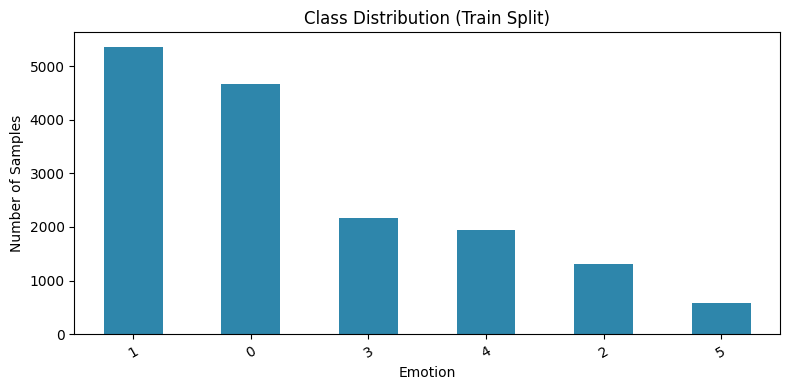

In [67]:
# Class distribution in train split
class_counts = pd.Series(dataset['train']['label']).value_counts().sort_values(ascending=False)
display(class_counts.to_frame('count'))

plt.figure(figsize=(8, 4))
class_counts.plot(kind='bar', color='#2E86AB')
plt.title('Class Distribution (Train Split)')
plt.xlabel('Emotion')
plt.ylabel('Number of Samples')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

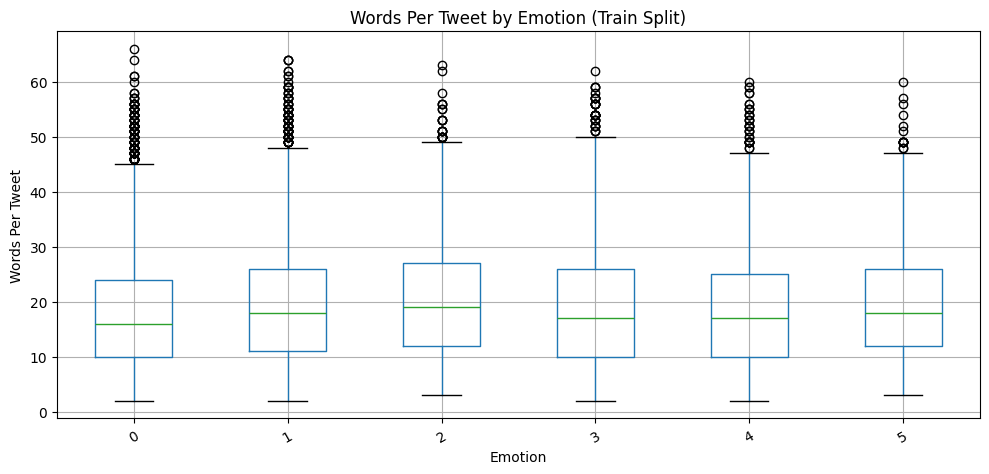

In [68]:
train_word_count = pd.DataFrame({
    'label_name': dataset['train']['label'],
    'Words Per Tweet': [len(str(t).split()) for t in dataset['train']['text']]
})

train_word_count.boxplot('Words Per Tweet', by='label_name', figsize=(10, 5))
plt.title('Words Per Tweet by Emotion (Train Split)')
plt.suptitle('')
plt.xlabel('Emotion')
plt.ylabel('Words Per Tweet')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Text Preprocessing

Use exactly the same preprocessing pipeline for all splits so the model sees text in the same format during:

Training (train)
Tuning/evaluation (validation)
Final evaluation or inference (test)

In [69]:
import re

# Expand common contractions first, then keep only lowercase words.
contraction_map = {
    "isn't": "is not", "isnt": "is not",
    "didn't": "did not", "didnt": "did not",
    "don't": "do not", "dont": "do not",
    "can't": "can not", "cant": "can not",
    "won't": "will not", "wont": "will not",
    "i'm": "i am", "im": "i am",
    "you're": "you are", "youre": "you are",
    "it's": "it is", "its": "it is",
    "that's": "that is", "thats": "that is",
    "there's": "there is", "theres": "there is",
    "we're": "we are", "were": "we are",
    "they're": "they are", "theyre": "they are",
    "i've": "i have", "ive": "i have",
    "we've": "we have", "weve": "we have",
    "they've": "they have", "theyve": "they have",
    "i'll": "i will", "ill": "i will",
    "you'll": "you will", "youll": "you will",
    "we'll": "we will", "well": "we will",
    "they'll": "they will", "theyll": "they will",
    "i'd": "i would", "id": "i would",
    "you'd": "you would", "youd": "you would",
    "we'd": "we would", "wed": "we would",
    "they'd": "they would", "theyd": "they would"
}

def preprocess_text(text):
    text = str(text).lower().strip()

    # Replace contractions as full-word matches only.
    for short_form, full_form in contraction_map.items():
        text = re.sub(rf"\b{re.escape(short_form)}\b", full_form, text)

    # Keep only alphabetic words and spaces.
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply preprocessing directly to the text column.
dataset = dataset.map(lambda x: {'text': preprocess_text(x['text']),"label": x["label"]})
print(dataset['train'][:10])

Map: 100%|██████████| 2000/2000 [00:02<00:00, 762.71 examples/s]

                                                text label
0      i did not feel humiliated name text dtype str   [0]
1  i can go from feeling so hopeless to so damned...   [0]
2  i am grabbing a minute to post i feel greedy w...   [3]
3  i am ever feeling nostalgic about the fireplac...   [2]
4           i am feeling grouchy name text dtype str   [3]
5  i have been feeling a little burdened lately w...   [0]
6  i have been taking or milligrams or times reco...   [5]
7  i feel as confused about life as a teenager or...   [4]
8  i have been with petronas for years i feel tha...   [1]
9            i feel romantic too name text dtype str   [2]


### Tokenization

In [70]:
from transformers import AutoTokenizer
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [71]:
text = "I love Machine Learning!. Tokenization is awesome"
encoded_text = tokenizer(text)
print(encoded_text)

{'input_ids': [101, 1045, 2293, 3698, 4083, 999, 1012, 19204, 3989, 2003, 12476, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [72]:

tokens = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)
print(tokens)
     

['[CLS]', 'i', 'love', 'machine', 'learning', '!', '.', 'token', '##ization', 'is', 'awesome', '[SEP]']


In [73]:

tokenizer.vocab_size, tokenizer.model_max_length


(30522, 512)

### Tokenization of Emotion Dataset

In [74]:
dataset.reset_format()

In [83]:
def tokenize(batch):
    # Shorter sequence length speeds up CPU training a lot
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=48)

df_encoded = dataset.map(tokenize, batched=True,batch_size=None)


Map: 100%|██████████| 2000/2000 [00:00<00:00, 3603.64 examples/s]


In [84]:
print(tokenize(dataset['train'][:2]))

{'input_ids': [[101, 1045, 2106, 2025, 2514, 26608, 2171, 3793, 26718, 18863, 2358, 2099, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 2171, 3793, 26718, 18863, 2358, 2099, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [85]:
df_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

### Model Building

In [86]:
import torch
from transformers import AutoModelForSequenceClassification

num_labels = len(classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels = num_labels).to(device)
     

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1960.71it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### training

In [87]:
from transformers import TrainingArguments

# CPU-optimized fast training config
batch_size = 64
model_name = "distilbert-finetuned-emotion-fast"

training_args = TrainingArguments(
    output_dir=model_name,
    num_train_epochs=2,
    learning_rate=5e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy="no",
    save_strategy="epoch",
    save_total_limit=2,
    logging_steps=50,
    report_to="none",
    disable_tqdm=False
)

In [88]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels, preds, average='weighted')
  acc = accuracy_score(labels, preds)
  return {"accuracy": acc, "f1": f1}


In [89]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=df_encoded['train'],
    eval_dataset=df_encoded['validation'],
    compute_metrics=compute_metrics,
    processing_class=tokenizer
 )

In [90]:
trainer.train()

Step,Training Loss


KeyboardInterrupt: 

In [ ]:
preds_outputs = trainer.predict(df_encoded['test'])
preds_outputs.metrics

In [ ]:


# Save artifacts for Streamlit inference
artifact_dir = "distilbert-finetuned-emotion-fast"
os.makedirs(artifact_dir, exist_ok=True)

id2label = {i: label for i, label in enumerate(classes)}
label2id = {label: i for i, label in id2label.items()}

# Persist labels in config so pipeline/from_pretrained picks them automatically
model.config.id2label = id2label
model.config.label2id = label2id

trainer.save_model(artifact_dir)
tokenizer.save_pretrained(artifact_dir)

with open(os.path.join(artifact_dir, "label_mapping.json"), "w", encoding="utf-8") as f:
    json.dump({"id2label": id2label, "label2id": label2id}, f, indent=2)

with open(os.path.join(artifact_dir, "train_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(train_output.metrics, f, indent=2)

print(f"Saved Streamlit-ready artifacts in: {artifact_dir}")
print("Files:", sorted(os.listdir(artifact_dir)))

d:\vscode\E-Commerce-Review-Intelligence-System\torch\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


d:\vscode\E-Commerce-Review-Intelligence-System\torch\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


ValueError: The model did not return a loss from the inputs, only the following keys: logits. For reference, the inputs it received are input_ids,attention_mask.